# Concrete


<a class="reference download internal" download="" href="https://github.com/simpsoba/benchmarks/blob/master/benchmarks/solid-0203/main.ipynb">
  <code class="xref download docutils literal notranslate">
    <span class="pre">Download</span>
  </code>
</a>


In [ ]:
import xara
from matplotlib import pyplot as plt
import numpy as np

import math

def _bezier3(xi,   x0, x1, x2,   y0, y1, y2):
    '''
    a quadratic bezier curve. gives the yi at xi, from 3 control points
    '''
    A = x0 - 2.0 * x1 + x2
    B = 2.0 * (x1 - x0)
    C = x0 - xi
    if abs(A) < 1.0e-12:
        x1 = x1 + 1.0E-6 * (x2 - x0)
        A = x0 - 2.0 * x1 + x2
        B = 2.0 * (x1 - x0)
        C = x0 - xi
    if A == 0.0:
        return 0.0
    D = B * B - 4.0 * A * C
    t = (math.sqrt(D) - B) / (2.0 * A)
    return (y0 - 2.0 * y1 + y2) * t * t + 2.0 * (y1 - y0) * t + y0

def _get_lch_ref(E,ft,Gt,fc,ec,Gc):
    '''
    compute a reference characteristic length
    when Gt and Gc are computed from equations
    '''

    # min lch for tension
    et_el = ft/E # no damage at peak
    Gt_min = ft*et_el/2.0
    hmin_t = Gt/Gt_min/100.0

    # min lch for compression
    ec1 = fc/E
    ec_pl = (ec-ec1)*0.4 + ec1
    Gc_min = fc*(ec-ec_pl)/2.0
    hmin_c = Gc/Gc_min/100.0

    # return the minimum
    return min(hmin_t, hmin_c)

def _make_tension(E, ft, Gt):
    '''
    a trilinar hardening-softening law for tensile response
    '''
    f0 = ft*0.9
    f1 = ft
    e0 = f0/E
    e1 = f1/E*1.5
    ep = e1-f1/E
    f2 = ft/5.0
    f3 = 1.0e-3*ft
    w2 = Gt/ft
    w3 = 5.0*w2
    e2 = w2 + f2/E + ep
    if e2 <= e1: e2 = e1*1.001
    e3 = w3 + f3/E + ep
    if e3 <= e2: e3 = e2*1.001
    e4 = e3*10.0
    Te = [0.0,  e0,  e1,  e2,  e3,  e4] # total strain points
    Ts = [0.0,  f0,  f1,  f2,  f3,  f3] # nominal stress points
    Td = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0] # initialize damage list
    Tpl = [0.0, 0.0, ep, e2*0.9, e3*0.8, e3*0.8] # desired values of equivalent plastic strains
    for i in range(2, len(Te)):
        xi = Te[i]
        si = Ts[i]
        xipl = Tpl[i]
        xipl_max = xi-si/E
        xipl = min(xipl, xipl_max)
        qi = (xi-xipl)*E
        Td[i] = 1.0-si/qi # compute damage
    return (Te, Ts, Td)

def _make_compression(E, fc, ec, Gc):
    '''
    a quadratic hardening followed by linear softening for compressive response
    '''
    fc0 = fc/2.0
    ec0 = fc0/E
    ec1 = fc/E
    fcr = fc*1.0e-1
    ec_pl = (ec-ec1)*0.4 + ec1
    Gc1 = fc*(ec-ec_pl)/2.0
    Gc2 = max(Gc1*1.0e-2, Gc-Gc1)
    ecr = ec + 2.0*Gc2/(fc+fcr)
    Ce = [0.0, ec0] # total strain points
    Cs = [0.0, fc0] # nominal stress points
    Cpl = [0.0, 0.0] # desired values of equivalent plastic strains
    nc = 10
    dec = (ec-ec0)/(nc-1)
    for i in range(nc-1):
        iec = ec0+(i+1.0)*dec
        Ce.append(iec)
        Cs.append(_bezier3(iec,  ec0, ec1, ec,  fc0, fc, fc))
        Cpl.append(Cpl[-1]+(iec-Cpl[-1])*0.7)
    # end of linear softening - begin residual plateau
    Ce.append(ecr)
    Cs.append(fcr)
    Cpl.append(Cpl[-1] + (ecr-Cpl[-1])*0.7)
    # extend to make a plateau
    Ce.append(ecr+ec0)
    Cs.append(fcr)
    Cpl.append(Cpl[-1])
    # compute damage now
    Cd = [0.0]*len(Ce)
    for i in range(2, len(Ce)):
        xi = Ce[i]
        si = Cs[i]
        xipl = Cpl[i]
        xipl_max = xi-si/E
        xipl = min(xipl, xipl_max)
        qi = (xi-xipl)*E
        Cd[i] = 1.0-si/qi # compute damage
    # Done
    return (Ce, Cs, Cd)



def make_concrete(E, ft, fc, ec, Gt, Gc):
    lch_ref = _get_lch_ref(E, ft, Gt, fc, ec, Gc)
    Te, Ts, Td = _make_tension(E, ft, Gt/lch_ref)
    Ce, Cs, Cd = _make_compression(E, fc, ec, Gc/lch_ref)
    return (Te, Ts, Td, Ce, Cs, Cd, lch_ref)



## Compression Analysis

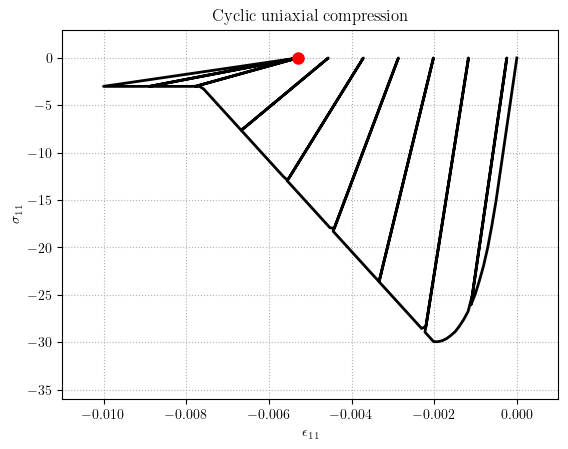

In [5]:


# the 2D model

ops = xara.Model(ndm=2, ndf=2)

# the material (units = N, mm)
E = 30000.0
v = 0.2
fc = 30.0
ft = fc/10.0
ec = 2.0*fc/E
Gt = 0.073*fc**0.18
Gc = 2.0*Gt*(fc/ft)**2
Te, Ts, Td, Ce, Cs, Cd, lch_ref = make_concrete(E, ft, fc, ec, Gt, Gc)

ops.nDMaterial('ASDConcrete3D', 1,
    E, v, # elasticity
    '-Te', *Te, '-Ts', *Ts, '-Td', *Td, # tensile law
    '-Ce', *Ce, '-Cs', *Cs, '-Cd', *Cd, # compressive law
    '-autoRegularization', lch_ref # use auto regularization: the input Gt and Gc are NOT specific fracture energies
    )

# the plane stress
#   ops.nDMaterial('PlaneStress', 2, 1)
ops.section("PlaneStress", 1, 1, 1.0)

# a triangle with lch = 250
lch = 250.0
ops.node(1, 0, 0)
ops.node(2, lch, 0)
ops.node(3, 0, lch)
ops.element('tri31', 1, (1, 2, 3), section=1) #  1.0, 'PlaneStress', 2)

# fixity
ops.fix(1,   1, 1)
ops.fix(2,   0, 1)
ops.fix(3,   1, 0)

# a simple ramp
ops.timeSeries('Linear', 1)

# imposed  strain
emax = 0.01
cycles = np.linspace(0.0, emax, 10)

# begin plot
SX = [0.0]
SY = [0.0]
PX = [0.0]
PY = [0.0]
plt.ion()
fig, ax = plt.subplots(1,1)
ax.grid(linestyle=':')
ax.set(xlim=[-emax*1.1, emax*0.1],ylim=[-fc*1.2, fc*0.1])
ax.set_title('Cyclic uniaxial compression')
ax.set_xlabel(r'$\epsilon_{11}$')
ax.set_ylabel(r'$\sigma_{11}$')
the_line, = ax.plot(SX, SY, '-k', linewidth=2.0)
the_tip,  = ax.plot(PX, PY, 'or', fillstyle='full', markersize=8)

# some default analysis settings
ops.constraints('Transformation')
ops.numberer('Plain')
ops.system('FullGeneral')
ops.test('NormDispIncr', 1.0e-8, 10, 0)
ops.algorithm('Newton')

for icycle in range(1, len(cycles)):
    # get current plastic strain (if any)
    ep = -ops.nodeDisp(2)[0]/lch
    # impose strain
    current_strain = cycles[icycle]
    ops.pattern('Plain', 1, 1)
    ops.sp(2, 1, -current_strain*lch, pattern=1)
    # load
    # start from a percentage = ep/current_strain
    time_start = ep/current_strain
    ops.setTime(time_start)
    num_incr = max(1, int((current_strain-ep)/emax*100.0))
    time_incr = (1.0-time_start)/float(num_incr)
    ops.integrator('LoadControl', time_incr)
    ops.analysis('Static')
    for i in range(num_incr):
        ok = ops.analyze(1)
        if ok == 0:
            strain = ops.eleResponse(1, 'material', 1, 'strain')
            stress = ops.eleResponse(1, 'material', 1, 'stress')
            SX.append(strain[0])
            SY.append(stress[0])
            the_line.set_xdata(SX)
            the_line.set_ydata(SY)
            PX = [SX[-1]]
            PY = [SY[-1]]
            the_tip.set_xdata(PX)
            the_tip.set_ydata(PY)
            fig.canvas.draw()
            fig.canvas.flush_events()
        else:
            break
    if ok != 0:
        break

    # unload
    ops.remove('pattern', 1)
    ops.setTime(0.0)
    ops.integrator('LoadControl', 1.0)
    ops.analysis('Static')
    ok = ops.analyze(1)
    # plot the unload point
    strain = ops.eleResponse(1, 'material', 1, 'strain')
    stress = ops.eleResponse(1, 'material', 1, 'stress')
    SX.append(strain[0])
    SY.append(stress[0])
    the_line.set_xdata(SX)
    the_line.set_ydata(SY)
    PX = [SX[-1]]
    PY = [SY[-1]]
    the_tip.set_xdata(PX)
    the_tip.set_ydata(PY)
    fig.canvas.draw()
    fig.canvas.flush_events()

plt.ioff()
plt.show()

## Tension test

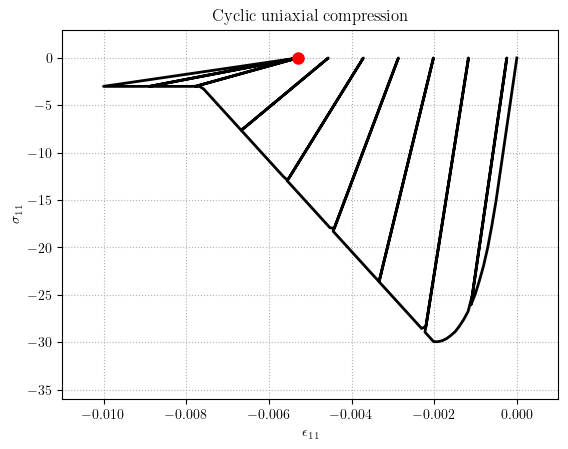

In [ ]:
# the 2D model
ops = xara.Model(ndm=2, ndf=2)

# the material (units = N, mm)
E = 30000.0
v = 0.2
fc = 30.0
ft = fc/10.0
ec = 2.0*fc/E
Gt = 0.073*fc**0.18
Gc = 2.0*Gt*(fc/ft)**2
Te, Ts, Td, Ce, Cs, Cd, lch_ref = make_concrete(E, ft, fc, ec, Gt, Gc)
ops.nDMaterial('ASDConcrete3D', 1,
    E, v, # elasticity
    '-Te', *Te, '-Ts', *Ts, '-Td', *Td, # tensile law
    '-Ce', *Ce, '-Cs', *Cs, '-Cd', *Cd, # compressive law
    '-autoRegularization', lch_ref # use auto regularization: the input Gt and Gc are NOT specific fracture energies
    )

# the plane stress
ops.nDMaterial('PlaneStress', 2, 1)

# a triangle with lch = 250
lch = 250.0
ops.node(1, 0, 0)
ops.node(2, lch, 0)
ops.node(3, 0, lch)
ops.element('tri31', 1,   1, 2, 3,   1.0, 'PlaneStress', 2)

# fixity
ops.fix(1,   1, 1)
ops.fix(2,   0, 1)
ops.fix(3,   1, 0)

# a simple ramp
ops.timeSeries('Linear', 1)

# imposed  strain
emax = 0.01
cycles = np.linspace(0.0, emax, 10)

# begin plot
SX = [0.0]
SY = [0.0]
PX = [0.0]
PY = [0.0]
plt.ion()
fig, ax = plt.subplots(1,1)
ax.grid(linestyle=':')
ax.set(xlim=[-emax*1.1, emax*0.1],ylim=[-fc*1.2, fc*0.1])
ax.set_title('Cyclic uniaxial compression')
ax.set_xlabel(r'$\epsilon_{11}$')
ax.set_ylabel(r'$\sigma_{11}$')
the_line, = ax.plot(SX, SY, '-k', linewidth=2.0)
the_tip, = ax.plot(PX, PY, 'or', fillstyle='full', markersize=8)

# some default analysis settings
ops.constraints('Transformation')
ops.numberer('Plain')
ops.system('FullGeneral')
ops.test('NormDispIncr', 1.0e-8, 10, 0)
ops.algorithm('Newton')

for icycle in range(1, len(cycles)):
    # get current plastic strain (if any)
    ep = -ops.nodeDisp(2)[0]/lch
    # impose strain
    current_strain = cycles[icycle]
    ops.pattern('Plain', 1, 1)
    ops.sp(2, 1, -current_strain*lch)
    # load
    # start from a percentage = ep/current_strain
    time_start = ep/current_strain
    ops.setTime(time_start)
    num_incr = max(1, int((current_strain-ep)/emax*100.0))
    time_incr = (1.0-time_start)/float(num_incr) 
    ops.integrator('LoadControl', time_incr)
    ops.analysis('Static')
    for i in range(num_incr):
        ok = ops.analyze(1)
        if ok == 0:
            strain = ops.eleResponse(1, 'material', 1, 'strain')
            stress = ops.eleResponse(1, 'material', 1, 'stress')
            SX.append(strain[0])
            SY.append(stress[0])
            the_line.set_xdata(SX)
            the_line.set_ydata(SY)
            PX = [SX[-1]]
            PY = [SY[-1]]
            the_tip.set_xdata(PX)
            the_tip.set_ydata(PY)
            fig.canvas.draw()
            fig.canvas.flush_events()
        else:
            break
    if ok != 0:
        break
    # unload
    ops.remove('pattern', 1)
    ops.setTime(0.0)
    ops.integrator('LoadControl', 1.0)
    ops.analysis('Static')
    ok = ops.analyze(1)
    # plot the unload point
    strain = ops.eleResponse(1, 'material', 1, 'strain')
    stress = ops.eleResponse(1, 'material', 1, 'stress')
    SX.append(strain[0])
    SY.append(stress[0])
    the_line.set_xdata(SX)
    the_line.set_ydata(SY)
    PX = [SX[-1]]
    PY = [SY[-1]]
    the_tip.set_xdata(PX)
    the_tip.set_ydata(PY)
    fig.canvas.draw()
    fig.canvas.flush_events()

plt.ioff()
plt.show()

In [9]:
import matplotlib.animation as animation
from IPython.display import HTML

def plot_animation(SX, SY, title):
    fig, ax = plt.subplots()
    ax.grid(linestyle=':')
    ax.set(xlim=[-emax*1.1, emax*0.1], ylim=[-fc*1.2, fc*0.1])
    ax.set_title(title)
    ax.set_xlabel(r'$\epsilon_{11}$')
    ax.set_ylabel(r'$\sigma_{11}$')

    line, = ax.plot([], [], '-k', linewidth=2.0)
    tip,  = ax.plot([], [], 'or', markersize=8)

    def update(i):
        line.set_data(SX[:i+1], SY[:i+1])
        tip.set_data([SX[i]], [SY[i]])
        return line, tip

    anim = animation.FuncAnimation(
        fig, update, frames=len(SX), interval=50, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

plot_animation(SX, SY, 'Cyclic uniaxial tension')